In [1]:
import pandas as pd
import numpy as np

from utils.config import load_config
from preprocessing.house_prices_preprocessing import HousePricesPreprocessor
from models.dl.train import train_model
from models.dl.training_history import show_dl_training_history

In [2]:
config = load_config()

data = pd.read_csv(config["paths"]["train"])

# --- разделяем target ---
target = "SalePrice"

# логарифмируем таргет
y = np.log1p(data[target])

X = data.drop(columns=[target])

# --- preprocessing ---
preprocessor = HousePricesPreprocessor(outlier_quantile=0.95)

X_prepared = preprocessor.fit_transform(X)

X_prepared.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageFinish_Unf,GarageFinish_Fin,GarageFinish_None,BsmtFinType1_GLQ,BsmtFinType1_ALQ,BsmtFinType1_Unf,BsmtFinType1_Rec,BsmtFinType1_BLQ,BsmtFinType1_None,BsmtFinType1_LwQ
0,0.073375,-0.208804,-0.332210,0.651479,-0.517200,1.050994,0.878668,0.739648,0.667140,-0.327561,...,0,0,0,1,0,0,0,0,0,0
1,-0.872563,0.646406,-0.009592,-0.071836,2.179628,0.156734,-0.429577,-0.654947,1.327216,-0.327561,...,0,0,0,0,1,0,0,0,0,0
2,0.073375,-0.037762,0.453294,0.651479,-0.517200,0.984752,0.830215,0.497729,0.133255,-0.327561,...,0,0,0,1,0,0,0,0,0,0
3,0.309859,-0.493874,-0.023619,0.651479,-0.517200,-1.863632,-0.720298,-0.654947,-0.521967,-0.327561,...,1,0,0,0,1,0,0,0,0,0
4,0.073375,0.874462,1.297710,1.374795,-0.517200,0.951632,0.733308,1.835402,0.543376,-0.327561,...,0,0,0,1,0,0,0,0,0,0


In [3]:
model, history = train_model(X_prepared, y)

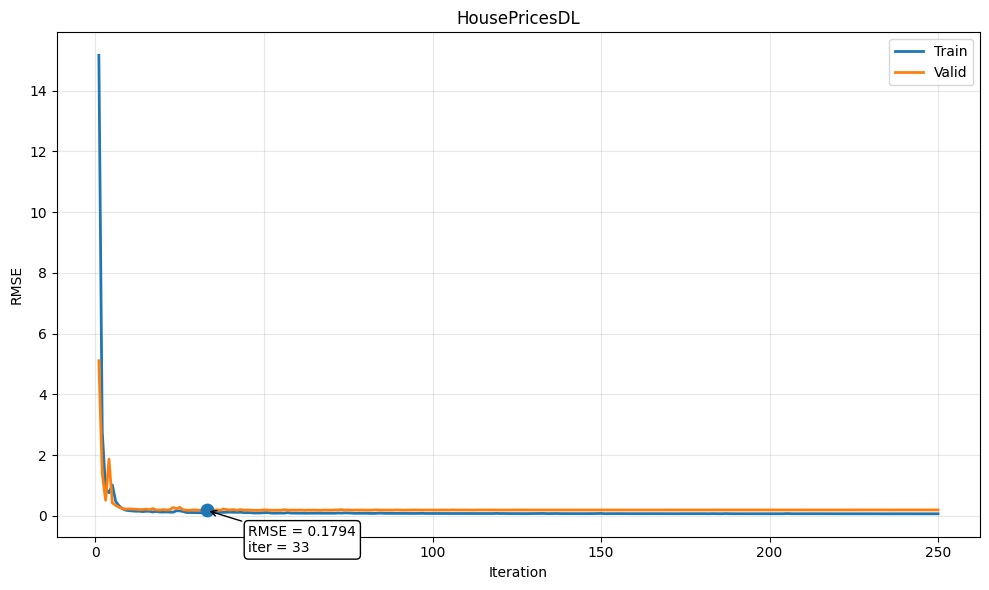

In [4]:
show_dl_training_history(history)

In [5]:
np.min(history['valid_scores'])

np.float64(0.179445132292209)

# DL модель (Fully Connected): результаты и выводы

## Задача

Предсказать цену дома (`SalePrice`) на основе признаков с помощью полносвязной нейронной сети.

---

## Результаты DL модели (log target)

| Model        | RMSE     |
| ------------ | -------- |
| HousePricesDL | ~0.18   |

---

## Интерпретация

### 1. Сравнение с ML моделями

Лучшие результаты:

- CatBoost → RMSE ≈ 0.127
- Ridge → RMSE ≈ 0.129
- DL → RMSE ≈ 0.18

Нейронная сеть показывает **хуже результат**, чем классические ML модели

---

### 2. Как интерпретировать RMSE

RMSE ≈ 0.18 означает:

exp(0.18) ≈ 1.20

Ошибка модели ≈ 20%

То есть:

- если дом стоит 200 000
- ошибка ≈ ±40 000

---

### 3. Анализ обучения (по графику)

По графику видно:

- в начале ошибка очень высокая (нестабильное обучение)
- затем происходит резкое падение
- после ~30 итераций модель выходит на плато
- train и valid почти совпадают

Это означает:

- модель быстро сходится
- переобучения практически нет
- но качество ограничено → модель недообучается (underfitting)

---

### 4. Почему DL хуже работает

Основные причины:

1. **Табличные данные**
   → нейросети хуже работают, чем бустинг

2. **Мало данных**
   → DL требует больше данных

3. **Простая архитектура**
   → недостаточно мощности модели

4. **Нет feature engineering внутри сети**
   → бустинг автоматически ловит сложные зависимости

---

## Выводы

- DL модель значительно уступает бустингу
- ошибка ≈ **20%**, что хуже ML подходов
- модель быстро сходится, но упирается в потолок качества
- признаковая структура данных лучше подходит для бустинга

---

## Итог

Для задачи House Prices:

- **лучший выбор → Gradient Boosting (CatBoost / XGBoost / LightGBM)**
- DL — скорее эксперимент, чем оптимальное решение